# All about plotting
The plotting routines are more modular than previously shown. This notebook will demonstarte the cababilities and flexibilities of the plotting routines. 

In [1]:
from CoolProp.CoolProp import AbstractState
import matplotlib.pyplot as plt

from refrigerationtoolbox.cycle.BasicHeatExchanger import BasicHeatExchanger
from refrigerationtoolbox.cycle.Compressor import celsius_to_kelvin_coeffs
from refrigerationtoolbox.cycle.Cycle import Cycle
from refrigerationtoolbox.cycle.EffCompressor import EffCompressor
from refrigerationtoolbox.cycle.PlateHeatExchanger import PlateHeatExchanger
from refrigerationtoolbox.cycle.PolynomialCompressor import PolynomialCompressor
from refrigerationtoolbox.plotter.CyclePlotter import CyclePlotter
import refrigerationtoolbox.plotter.CyclePlotter as CycPl

In [2]:
# Setting up the basic testcase parameters again
Te = 0 + 273.15  # [K] evaporation temperature on the low pressure side
Tc = 30 + 273.15 # [K] condensation temperature on the high pressure side
sh = 0           # [K] superheating at compressor inlet
sc = 5           # [K] subcooling at condensor outlet

# Refrigerant used in the refrigeration cycle
fluid_ref_R134a = AbstractState("HEOS", "R134a")
fluid_ref_R32 = AbstractState("HEOS", "R32")

# using water in the secondary cycles of the evaporators and condensers
fluid_sec_evap = AbstractState("HEOS", "Water")
fluid_sec_cond = AbstractState("HEOS", "Water")

# Efficiency-based compressor parameters
is_eff = 0.8  # Isentropic efficiency
vol_eff = 0.9 # Volumetric efficiency
N = 1500 / 60 # [Hz] Compressor frequency (1500 rpm / 60)
Vd = 5e-5     # [m³] Displaced volume per revolution

# Boundary condition at heat exchangers
m_flow_sec_cond = 0.1         # [kg/s] Mass flow rate at the inlet of the secondary cycle of the condenser
p_sec_cond = 1e5            # [Pa] Pressure in the secondary cycle of the condenser
T_sec_in_cond = 20+273.15   # [K] Temperature at the inlet of the secondary cycle of the condenser
m_flow_sec_evap = 0.5       # [kg/s] Mass flow rate at the inlet of the secondary cycle of the evaporator
p_sec_evap = 1e5            # [Pa] Pressure in the secondary cycle of the evaporator
T_sec_in_evap = 10+273.15   # [K] Temperature at the inlet of the secondary cycle of the evaporator



## 1. Customising log p-h and T-s diagrams

In [3]:
cycle_R134a = Cycle(fluid_ref_R134a, Te=0+273.15, Tc=30+273.15, sh=5.0, sc=5.0)

cycle_R134a.set_compressor(EffCompressor(fluid_ref_R134a, is_eff=is_eff, vol_eff=vol_eff, N=N, Vd=Vd))
cycle_R134a.set_condenser(BasicHeatExchanger(fluid_ref_R134a, fluid_sec_evap))
cycle_R134a.set_evaporator(BasicHeatExchanger(fluid_ref_R134a, fluid_sec_cond))
cycle_R134a.calc(m_flow_sec_cond=m_flow_sec_cond, p_sec_cond=p_sec_cond, T_sec_in_cond=T_sec_in_cond, m_flow_sec_evap=m_flow_sec_evap, p_sec_evap=p_sec_evap, T_sec_in_evap=T_sec_in_evap)

cycle_R32 = Cycle(fluid_ref_R32, Te=0+273.15, Tc=30+273.15, sh=5.0, sc=5.0)

cycle_R32.set_compressor(EffCompressor(fluid_ref_R32, is_eff=is_eff, vol_eff=vol_eff, N=N, Vd=Vd))
cycle_R32.set_condenser(BasicHeatExchanger(fluid_ref_R32, fluid_sec_evap))
cycle_R32.set_evaporator(BasicHeatExchanger(fluid_ref_R32, fluid_sec_cond))

cycle_R32.calc(m_flow_sec_cond=m_flow_sec_cond, p_sec_cond=p_sec_cond, T_sec_in_cond=T_sec_in_cond, m_flow_sec_evap=m_flow_sec_evap, p_sec_evap=p_sec_evap, T_sec_in_evap=T_sec_in_evap)

Cycle (refrigerant=R134a, Te=273.15, Tc=303.15, sh=5.0, sc=5.0)
   Q_heat: N/A kW, Q_ref: N/A kW, P_comp: 0.41 kW, COP_heat=N/A, COP_cool= N/A, m_flow=0.02 kg/s
   State 1: T=278.15, P=292.80 kPa, h=403.07 kJ/kg, s=1.74 kJ/(kgK), rho=14.07 kg/m³
   State 2: T=316.65, P=770.20 kPa, h=428.82 kJ/kg, s=1.76 kJ/(kgK), rho=34.66 kg/m³
   State 3: T=298.15, P=770.20 kPa, h=234.55 kJ/kg, s=1.12 kJ/(kgK), rho=1207.35 kg/m³
   State 4: T=273.15, P=292.80 kPa, h=234.55 kJ/kg, s=1.13 kJ/(kgK), rho=78.77 kg/m³
Cycle (refrigerant=R32, Te=273.15, Tc=303.15, sh=5.0, sc=5.0)
   Q_heat: N/A kW, Q_ref: N/A kW, P_comp: 1.06 kW, COP_heat=N/A, COP_cool= N/A, m_flow=0.02 kg/s
   State 1: T=278.15, P=813.10 kPa, h=521.37 kJ/kg, s=2.18 kJ/(kgK), rho=21.37 kg/m³
   State 2: T=339.34, P=1927.51 kPa, h=565.48 kJ/kg, s=2.20 kJ/(kgK), rho=42.37 kg/m³
   State 3: T=298.15, P=1927.51 kPa, h=245.51 kJ/kg, s=1.16 kJ/(kgK), rho=962.56 kg/m³
   State 4: T=273.15, P=813.10 kPa, h=245.51 kJ/kg, s=1.17 kJ/(kgK), rho=136.16 

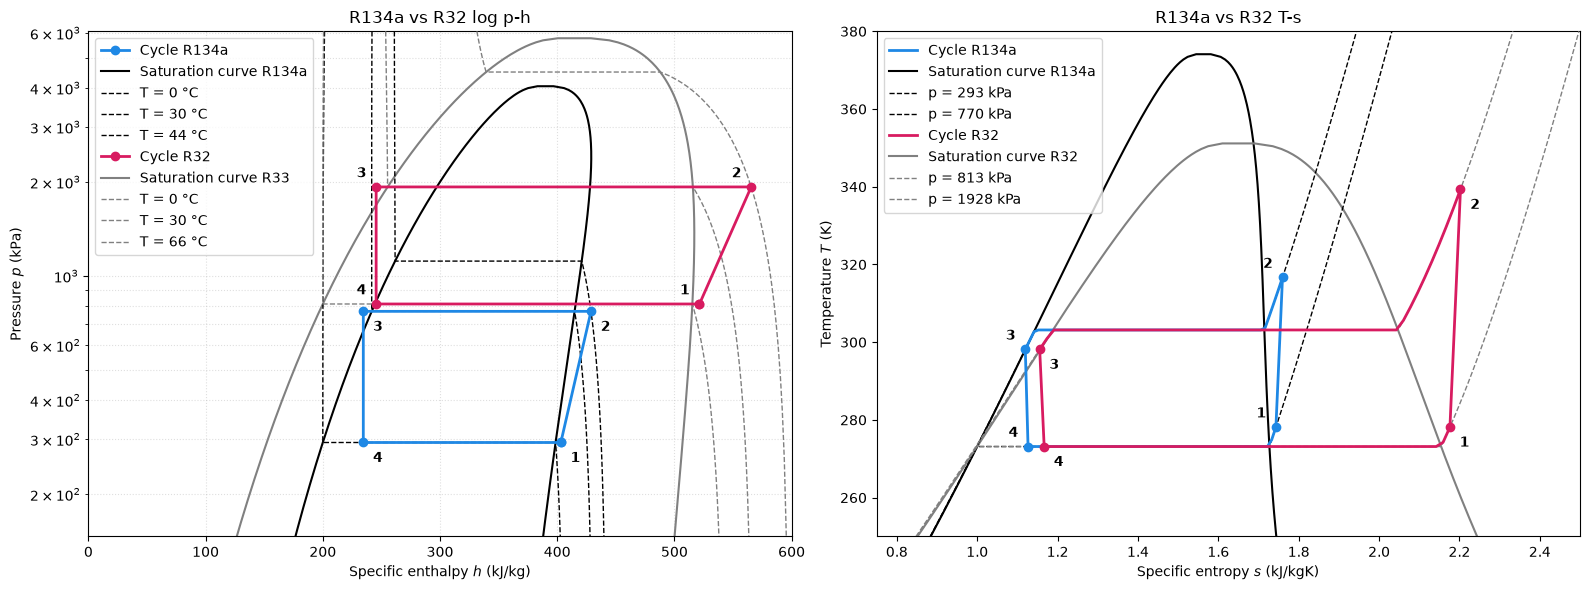

In [4]:
plotter = CyclePlotter()

p_min = cycle_R134a.pe * 0.5               # a little below evaporating pressure
p_max = fluid_ref_R32.p_critical() * 1.05
h_lo = 0
h_hi = 600

fig, (ax_ph, ax_Ts)= plt.subplots(1, 2, figsize=(16, 6))
ax_ph.set_yscale("log")
ax_ph.set_ylim(p_min/1e3, p_max/1e3)
ax_ph.set_xlim(h_lo, h_hi)
ax_ph.set_xlabel("Specific enthalpy $h$ (kJ/kg)")
ax_ph.set_ylabel("Pressure $p$ (kPa)")
ax_ph.grid(True, which="both", ls=":", alpha=0.4)
ax_ph.set_title("R134a vs R32 log p-h")

plotter.plot_ph_cycle(ax_ph, cycle=cycle_R134a, color=CycPl.BLUE, xytext=(7, -14), label="Cycle R134a")
plotter.plot_ph_dome(ax_ph, cycle_R134a.fluid, color="black", lw=1.5, linestyle="-", label="Saturation curve R134a")
plotter.plot_ph_isotherms(ax_ph, cycle_R134a.fluid, p_min=p_min, p_max=p_max,
                          temps=[cycle_R134a.Te, cycle_R134a.Tc, cycle_R134a.T2], colors=["black"])

plotter.plot_ph_cycle(ax_ph, cycle_R32, color=CycPl.RED, xytext=(-14, 7), label="Cycle R32")
plotter.plot_ph_dome(ax_ph, cycle_R32.fluid, color="grey", lw=1.5, linestyle="-", label="Saturation curve R33")
plotter.plot_ph_isotherms(ax_ph, cycle_R32.fluid, p_min=p_min, p_max=p_max,
                          temps=[cycle_R32.Te, cycle_R32.Tc, cycle_R32.T2], colors=["grey"])
ax_ph.legend(loc="best", fontsize=10)

T_min = 250
T_max = 380
s_lo = 0.75
s_hi = 2.5

ax_Ts.set_xlim(s_lo, s_hi)
ax_Ts.set_ylim(T_min, T_max)
ax_Ts.set_title("R134a vs R32 T-s")
ax_Ts.set_xlabel("Specific entropy $s$ (kJ/kgK)")
ax_Ts.set_ylabel("Temperature $T$ (K)")

plotter.plot_ts_cycle(ax_Ts, cycle=cycle_R134a, color=CycPl.BLUE, xytext=(-14, 7), label="Cycle R134a")
plotter.plot_ts_dome(ax_Ts, cycle_R134a.fluid, color="black", lw=1.5, label="Saturation curve R134a")
plotter.plot_ts_isobars(ax_Ts, cycle_R134a.fluid, T_min=T_min, T_max=T_max,
                        pressures=[cycle_R134a.pe, cycle_R134a.pc], colors=["black"])

plotter.plot_ts_cycle(ax_Ts, cycle=cycle_R32, color=CycPl.RED, xytext=(7, -14), label="Cycle R32")
plotter.plot_ts_dome(ax_Ts, cycle_R32.fluid, color="grey", lw=1.5, label="Saturation curve R32")
plotter.plot_ts_isobars(ax_Ts, cycle_R32.fluid, T_min=T_min, T_max=T_max,
                        pressures=[cycle_R32.pe, cycle_R32.pc], colors=["grey"])
ax_Ts.legend(loc="best", fontsize=10)

fig.tight_layout()